In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import os
import torch.nn as nn
from PIL import Image
import h5py
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
%autosave 30

cuda


Autosaving every 30 seconds


In [2]:
file_path = "../../../../../data/SVHN_single/SVHN_single_grey1.h5"

with h5py.File(file_path, "r") as f:
    print(f.keys())

with h5py.File(file_path, "r") as f:
    X_train = np.array(f["X_train"])
    y_train = np.array(f["y_train"])

    X_val = np.array(f["X_val"])
    y_val = np.array(f["y_val"])

    X_test = np.array(f["X_test"])
    y_test = np.array(f["y_test"])

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']>
(42000, 32, 32) (42000,)
(60000, 32, 32) (60000,)
(18000, 32, 32) (18000,)


In [3]:
import random
import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 尽量让 CUDA 计算确定
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
g = torch.Generator()
g.manual_seed(42)

set_seed(42)

In [4]:
import h5py
import numpy as np
from PIL import Image
from torch.utils.data import Dataset


class SVHNGreyDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        """
        :param root_dir: SVHN_single_grey1.h5 文件路径
        :param split: "train", "val", or "test"
        :param transform: 对图片进行的预处理操作
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        split_map = {
            "train": ("X_train", "y_train"),
            "val": ("X_val", "y_val"),
            "test": ("X_test", "y_test"),
        }

        if split not in split_map:
            raise ValueError("split must be one of: 'train', 'val', 'test'")

        x_key, y_key = split_map[split]

        with h5py.File(self.root_dir, "r") as f:
            self.data = np.array(f[x_key])
            self.labels = np.array(f[y_key])

        # 确保 label 是 int64，适配 CrossEntropyLoss
        self.labels = self.labels.astype(np.int64)

        # 如果某些 SVHN 文件里用 10 表示数字 0，就修正成 0
        self.labels[self.labels == 10] = 0

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]

        # SVHN_single_grey1.h5 通常是 [32, 32] 灰度图
        # 转成 PIL Image，模式为 L 表示 grayscale
        img = Image.fromarray(img.astype("uint8"), mode="L")

        if self.transform:
            img = self.transform(img)
        
        return img, label

In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader

file_path = "../../../../../data/SVHN_single/SVHN_single_grey1.h5"

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5],
    ),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5],
    ),
])

train_dataset = SVHNGreyDataset(
    root_dir=file_path,
    split="train",
    transform=train_transform,
)

val_dataset = SVHNGreyDataset(
    root_dir=file_path,
    split="val",
    transform=test_transform,
)

test_dataset = SVHNGreyDataset(
    root_dir=file_path,
    split="test",
    transform=test_transform,
)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True,
    generator=g,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    generator=g,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    generator=g,
)

In [6]:
print(len(train_loader))
print(len(test_loader))

164
71


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WideBasicBlock(nn.Module):
    """
    WideResNet basic block for CIFAR-10.

    Structure:
        BN -> ReLU -> Conv
        BN -> ReLU -> Dropout -> Conv
        + shortcut

    This is closer to pre-activation ResNet / WideResNet style.
    """

    def __init__(self, in_channels, out_channels, stride=1, drop_rate=0.0):
        super().__init__()

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=drop_rate) if drop_rate > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                padding=0,
                bias=False,
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.bn1(x)
        out = self.relu1(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu2(out)
        out = self.dropout(out)
        out = self.conv2(out)

        out = out + residual
        return out


class WideResNet(nn.Module):
    """
    CIFAR-style WideResNet.

    depth should satisfy:
        depth = 6n + 4

    Examples:
        WRN-16-4: depth=16, widen_factor=4
        WRN-28-4: depth=28, widen_factor=4
        WRN-28-10: depth=28, widen_factor=10
    """

    def __init__(self, depth=28, widen_factor=6, drop_rate=0.2, num_classes=10):
        super().__init__()

        assert (depth - 4) % 6 == 0, "depth should be 6n + 4"
        n = (depth - 4) // 6

        channels = [
            16,
            16 * widen_factor,
            32 * widen_factor,
            64 * widen_factor,
        ]

        self.conv1 = nn.Conv2d(
            1,
            channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        self.stage1 = self._make_stage(
            in_channels=channels[0],
            out_channels=channels[1],
            num_blocks=n,
            stride=1,
            drop_rate=drop_rate,
        )

        self.stage2 = self._make_stage(
            in_channels=channels[1],
            out_channels=channels[2],
            num_blocks=n,
            stride=2,
            drop_rate=drop_rate,
        )

        self.stage3 = self._make_stage(
            in_channels=channels[2],
            out_channels=channels[3],
            num_blocks=n,
            stride=2,
            drop_rate=drop_rate,
        )

        self.bn = nn.BatchNorm2d(channels[3])
        self.relu = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[3], num_classes)

        self._init_weights()

    def _make_stage(self, in_channels, out_channels, num_blocks, stride, drop_rate):
        layers = []

        layers.append(
            WideBasicBlock(
                in_channels=in_channels,
                out_channels=out_channels,
                stride=stride,
                drop_rate=drop_rate,
            )
        )

        for _ in range(1, num_blocks):
            layers.append(
                WideBasicBlock(
                    in_channels=out_channels,
                    out_channels=out_channels,
                    stride=1,
                    drop_rate=drop_rate,
                )
            )

        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu",
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv1(x)  # [B, 16, 32, 32]

        x = self.stage1(x)  # [B, 16*k, 32, 32]
        x = self.stage2(x)  # [B, 32*k, 16, 16]
        x = self.stage3(x)  # [B, 64*k, 8, 8]

        x = self.bn(x)
        x = self.relu(x)

        x = self.avgpool(x)  # [B, 64*k, 1, 1]
        x = torch.flatten(x, 1)
        x = self.fc(x)  # [B, 10]

        return x

In [8]:
model = WideResNet(
    depth=28,
    widen_factor=4,
    drop_rate=0.2,
    num_classes=10,
).to(device)
print(model)
num_epochs=100
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.08, momentum=0.9, weight_decay=5e-4, nesterov=True
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)
# print(model)

WideResNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (stage1): Sequential(
    (0): WideBasicBlock(
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (shortcut): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    )
    (1): WideBasicBlock(
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [9]:
def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    aug_type=None,
    alpha=0.2,
):
    model.train()

    total_loss = 0.0
    total_correct = 0.0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).long()

        if aug_type == "mixup":
            x, y_a, y_b, lam = mixup_data(x, y, alpha=alpha)

            logits = model(x)
            loss = mix_criterion(criterion, logits, y_a, y_b, lam)

            preds = logits.argmax(dim=1)
            correct = (
                lam * (preds == y_a).float()
                + (1 - lam) * (preds == y_b).float()
            ).sum().item()

        elif aug_type == "cutmix":
            x, y_a, y_b, lam = cutmix_data(x, y, alpha=alpha)

            logits = model(x)
            loss = mix_criterion(criterion, logits, y_a, y_b, lam)

            preds = logits.argmax(dim=1)
            correct = (
                lam * (preds == y_a).float()
                + (1 - lam) * (preds == y_b).float()
            ).sum().item()

        else:
            logits = model(x)
            loss = criterion(logits, y)

            preds = logits.argmax(dim=1)
            correct = (preds == y).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_correct += correct
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).long()

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [10]:
train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_test_acc = 0.0
epoch = 0

In [11]:
from datetime import datetime

for _ in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    scheduler.step()
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "SVHN_single.pt")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} |"
        f"LR: {current_lr:.6f}"
    )
    epoch+=1

[2026-05-20 20:56:05] Epoch [1/100] Train Loss: 2.0613, Train Acc: 0.2572 | Test Loss: 1.7601, Test Acc: 0.4694 |LR: 0.079980
[2026-05-20 20:56:35] Epoch [2/100] Train Loss: 0.7467, Train Acc: 0.8448 | Test Loss: 0.6607, Test Acc: 0.8902 |LR: 0.079921
[2026-05-20 20:57:06] Epoch [3/100] Train Loss: 0.5517, Train Acc: 0.9160 | Test Loss: 0.7396, Test Acc: 0.8655 |LR: 0.079823
[2026-05-20 20:57:36] Epoch [4/100] Train Loss: 0.5030, Train Acc: 0.9314 | Test Loss: 0.5179, Test Acc: 0.9266 |LR: 0.079685
[2026-05-20 20:58:06] Epoch [5/100] Train Loss: 0.4807, Train Acc: 0.9379 | Test Loss: 0.5546, Test Acc: 0.9118 |LR: 0.079508
[2026-05-20 20:58:35] Epoch [6/100] Train Loss: 0.4602, Train Acc: 0.9438 | Test Loss: 0.5606, Test Acc: 0.9104 |LR: 0.079292
[2026-05-20 20:59:05] Epoch [7/100] Train Loss: 0.4500, Train Acc: 0.9469 | Test Loss: 0.5195, Test Acc: 0.9248 |LR: 0.079038
[2026-05-20 20:59:35] Epoch [8/100] Train Loss: 0.4390, Train Acc: 0.9487 | Test Loss: 0.4801, Test Acc: 0.9381 |LR: 0

In [12]:
import json

history = {
    "train_losses": train_losses,
    "train_accs": train_accs,
    "test_losses": test_losses,
    "test_accs": test_accs,
    "best_test_acc": best_test_acc,
}

with open("cifar100_history.json", "w") as f:
    json.dump(history, f, indent=4)

Best test acc: 0.9696


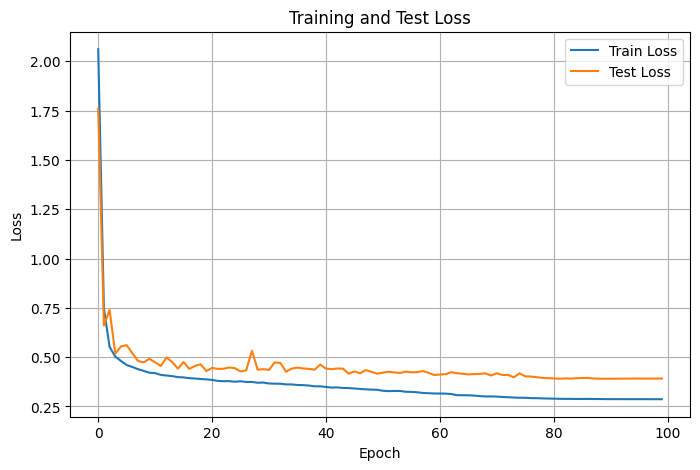

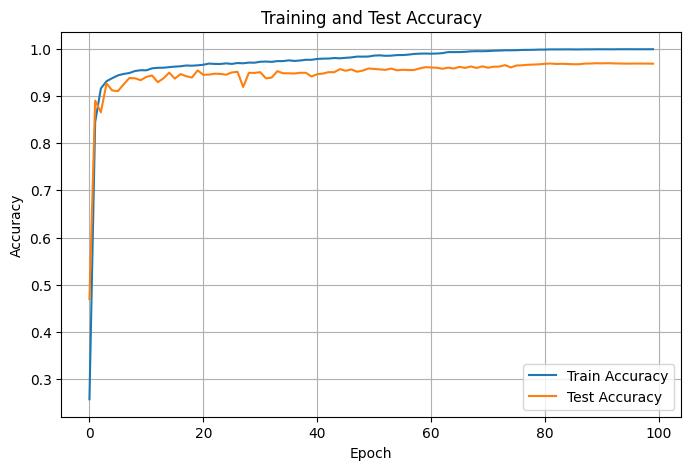

In [13]:
print(f"Best test acc: {best_test_acc:.4f}")
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()
# 0.9643

In [15]:
with torch.no_grad():
    model.eval()
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(test_acc)

0.9685555555555555
